In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ML Dataset.zip to ML Dataset.zip


In [ ]:
import zipfile

with zipfile.ZipFile("ML Dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os

print(os.listdir("/content/ML Dataset"))

['phone', 'Pen', 'bottle']


In [5]:
import os

dataset_path = "/content/ML Dataset"

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        print(
            f"{cls}: {len(os.listdir(class_path))} images"
        )

phone: 53 images
Pen: 54 images
bottle: 49 images


In [6]:
img_height = 128
img_width = 128
batch_size = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 156 files belonging to 3 classes.
Using 125 files for training.
Found 156 files belonging to 3 classes.
Using 31 files for validation.


In [7]:
print(train_ds.class_names)

['Pen', 'bottle', 'phone']


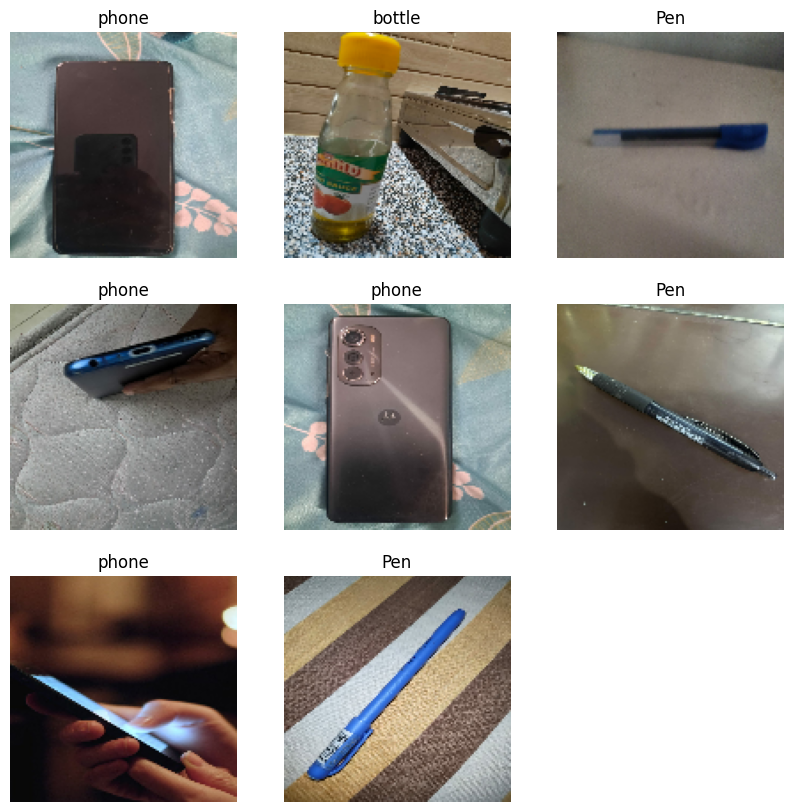

In [8]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(len(images)):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

plt.show()

In [9]:
model = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 325ms/step - accuracy: 0.3520 - loss: 1.1682 - val_accuracy: 0.3548 - val_loss: 1.0859
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.3600 - loss: 1.0978 - val_accuracy: 0.2258 - val_loss: 1.1190
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 397ms/step - accuracy: 0.4720 - loss: 1.0444 - val_accuracy: 0.4839 - val_loss: 1.1299
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - accuracy: 0.4880 - loss: 1.0199 - val_accuracy: 0.6452 - val_loss: 1.0547
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 379ms/step - accuracy: 0.6240 - loss: 0.8924 - val_accuracy: 0.5161 - val_loss: 1.0353
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 329ms/step - accuracy: 0.6960 - loss: 0.7930 - val_accuracy: 0.5484 - val_loss: 1.2163
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 376ms/step - accuracy: 0.7600 - loss: 0.6476 - val_accuracy: 0.6452 - val_loss: 1.1769
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 318ms/step - accuracy: 0.8160 - loss: 0.5209 - val_accuracy:

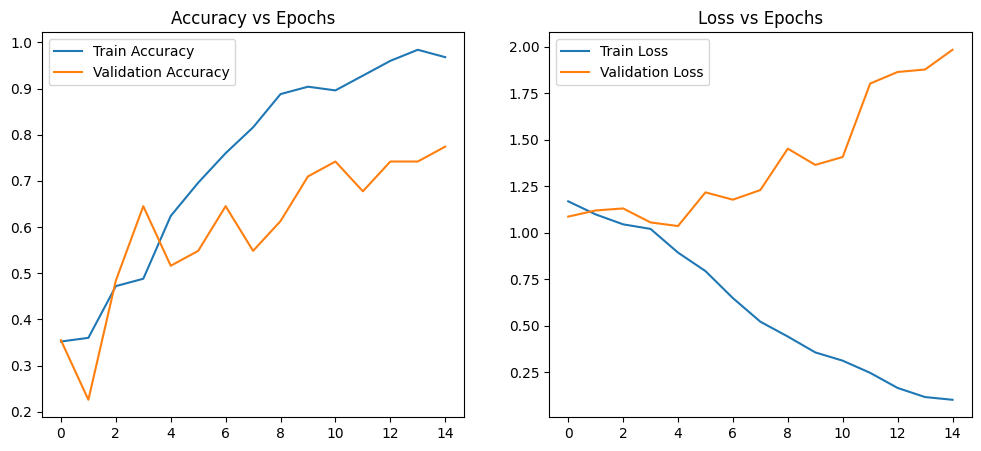

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

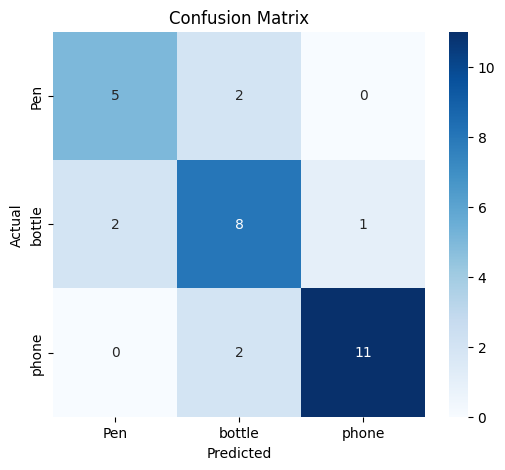

In [15]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.71      0.71      0.71         7
      bottle       0.67      0.73      0.70        11
       phone       0.92      0.85      0.88        13

    accuracy                           0.77        31
   macro avg       0.77      0.76      0.76        31
weighted avg       0.78      0.77      0.78        31



In [ ]:
# Experiment 2 -
#increasing Dropout and checking


In [17]:
model2 = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.65),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 434ms/step - accuracy: 0.3360 - loss: 1.2154 - val_accuracy: 0.3548 - val_loss: 1.0939
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.3760 - loss: 1.0949 - val_accuracy: 0.2258 - val_loss: 1.1042
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step - accuracy: 0.3920 - loss: 1.0874 - val_accuracy: 0.3226 - val_loss: 1.0867
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 392ms/step - accuracy: 0.3520 - loss: 1.1139 - val_accuracy: 0.2258 - val_loss: 1.1174
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - accuracy: 0.4160 - loss: 1.0871 - val_accuracy: 0.5806 - val_loss: 1.0600
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 320ms/step - accuracy: 0.6240 - loss: 1.0311 - val_accuracy: 0.3871 - val_loss: 1.0782
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.5920 - loss: 0.9765 - val_accuracy: 0.5806 - val_loss: 0.9983
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 426ms/step - accuracy: 0.6560 - loss: 0.8643 - val_accuracy

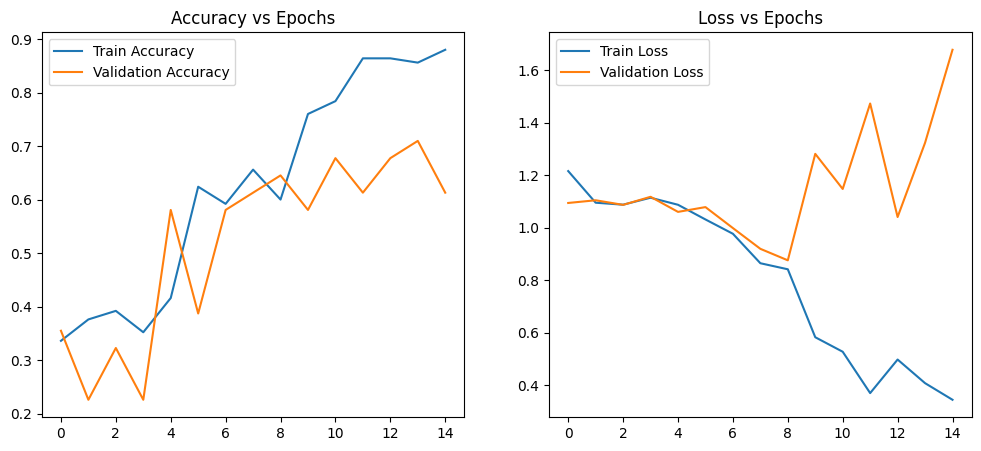

In [20]:
acc = history2.history['accuracy']
val_acc = history2.history['val_accuracy']

loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [21]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model2.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

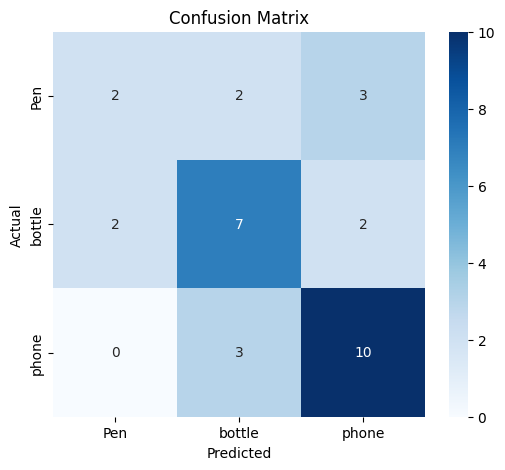

In [22]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.50      0.29      0.36         7
      bottle       0.58      0.64      0.61        11
       phone       0.67      0.77      0.71        13

    accuracy                           0.61        31
   macro avg       0.58      0.56      0.56        31
weighted avg       0.60      0.61      0.60        31



In [ ]:
#Experiment 3

In [25]:
model3 = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 423ms/step - accuracy: 0.3920 - loss: 1.4190 - val_accuracy: 0.2258 - val_loss: 1.2538
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 383ms/step - accuracy: 0.3680 - loss: 1.2319 - val_accuracy: 0.2903 - val_loss: 1.2207
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 327ms/step - accuracy: 0.4880 - loss: 1.2048 - val_accuracy: 0.6774 - val_loss: 1.1711
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 331ms/step - accuracy: 0.5040 - loss: 1.1401 - val_accuracy: 0.5806 - val_loss: 1.1189
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 382ms/step - accuracy: 0.5280 - loss: 1.0260 - val_accuracy: 0.6129 - val_loss: 1.0074
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 452ms/step - accuracy: 0.7040 - loss: 0.7850 - val_accuracy: 0.6452 - val_loss: 1.0431
Epoch 7/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 330ms/step - accuracy: 0.7280 - loss: 0.8051 - val_accuracy: 0.5806 - val_loss: 1.1601
Epoch 8/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 398ms/step - accuracy: 0.8160 - loss: 0.6190 - val_accuracy:

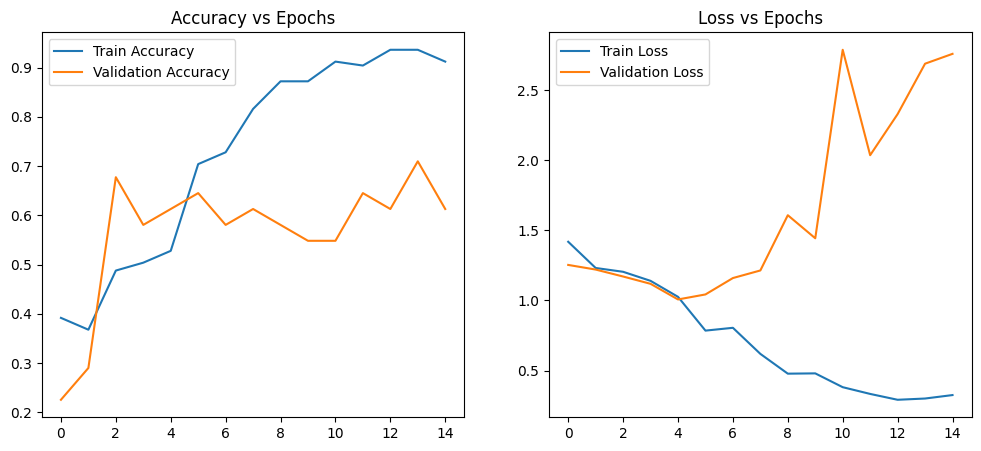

In [28]:
acc = history3.history['accuracy']
val_acc = history3.history['val_accuracy']

loss = history3.history['loss']
val_loss = history3.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [29]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model3.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

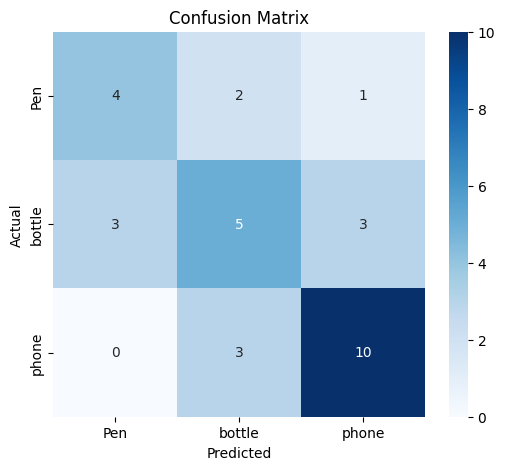

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [31]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.57      0.57      0.57         7
      bottle       0.50      0.45      0.48        11
       phone       0.71      0.77      0.74        13

    accuracy                           0.61        31
   macro avg       0.60      0.60      0.60        31
weighted avg       0.61      0.61      0.61        31



In [ ]:
#Experminet 4

In [39]:
model4 = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [40]:
model4.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 352ms/step - accuracy: 0.3600 - loss: 1.2786 - val_accuracy: 0.3548 - val_loss: 1.0981
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 327ms/step - accuracy: 0.3280 - loss: 1.0982 - val_accuracy: 0.3548 - val_loss: 1.0943
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 400ms/step - accuracy: 0.3680 - loss: 1.1002 - val_accuracy: 0.1935 - val_loss: 1.1168
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 388ms/step - accuracy: 0.4720 - loss: 1.0730 - val_accuracy: 0.2258 - val_loss: 1.1177
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.4640 - loss: 1.0261 - val_accuracy: 0.5161 - val_loss: 1.0641
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 311ms/step - accuracy: 0.4480 - loss: 1.0073 - val_accuracy: 0.3226 - val_loss: 1.1052
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 318ms/step - accuracy: 0.6560 - loss: 0.9033 - val_accuracy: 0.5806 - val_loss: 0.9621
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - accuracy: 0.6480 - loss: 0.8046 - val_accurac

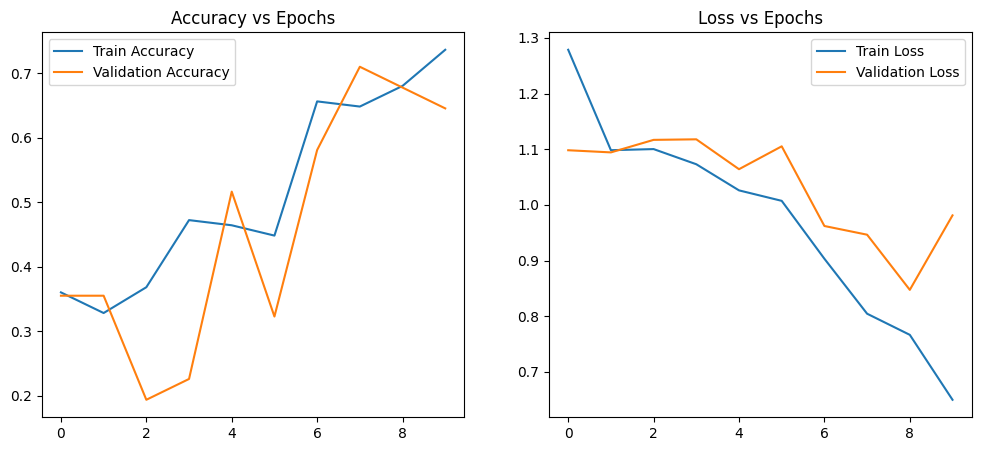

In [42]:
acc = history4.history['accuracy']
val_acc = history4.history['val_accuracy']

loss = history4.history['loss']
val_loss = history4.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [43]:
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model4.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

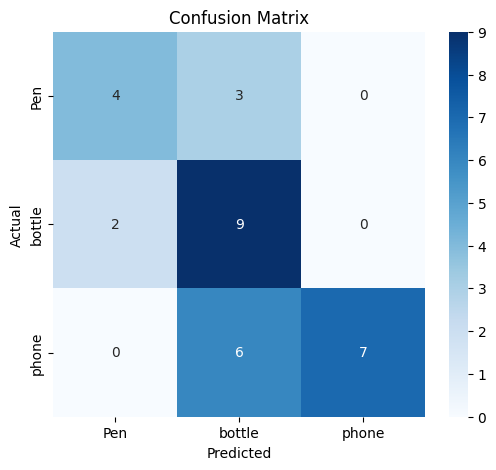

In [44]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [45]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.67      0.57      0.62         7
      bottle       0.50      0.82      0.62        11
       phone       1.00      0.54      0.70        13

    accuracy                           0.65        31
   macro avg       0.72      0.64      0.65        31
weighted avg       0.75      0.65      0.65        31



In [ ]:
#Experiment 5

In [51]:
img_height = 128
img_width = 128
batch_size = 7

train_ds_exp5 = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds_exp5 = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 156 files belonging to 3 classes.
Using 125 files for training.
Found 156 files belonging to 3 classes.
Using 31 files for validation.


In [52]:
print(train_ds_exp5.class_names)

['Pen', 'bottle', 'phone']


In [53]:
model5 = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

In [54]:
model5.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
history5 = model5.fit(
    train_ds_exp5,
    validation_data=val_ds_exp5,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 309ms/step - accuracy: 0.2880 - loss: 1.1368 - val_accuracy: 0.3548 - val_loss: 1.0911
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 362ms/step - accuracy: 0.3840 - loss: 1.0971 - val_accuracy: 0.6452 - val_loss: 1.0891
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 551ms/step - accuracy: 0.5120 - loss: 1.0734 - val_accuracy: 0.3871 - val_loss: 1.1078
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 415ms/step - accuracy: 0.3760 - loss: 1.0925 - val_accuracy: 0.3548 - val_loss: 1.0881
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.5280 - loss: 1.0610 - val_accuracy: 0.5806 - val_loss: 1.0108
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 299ms/step - accuracy: 0.6080 - loss: 0.8695 - val_accuracy: 0.3871 - val_loss: 1.1574
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 305ms/step - accuracy: 0.6960 - loss: 0.7006 - val_accuracy: 0.7742 - val_loss: 0.8680
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step - accuracy: 0.8240 - loss: 0.4951 - val_accuracy:

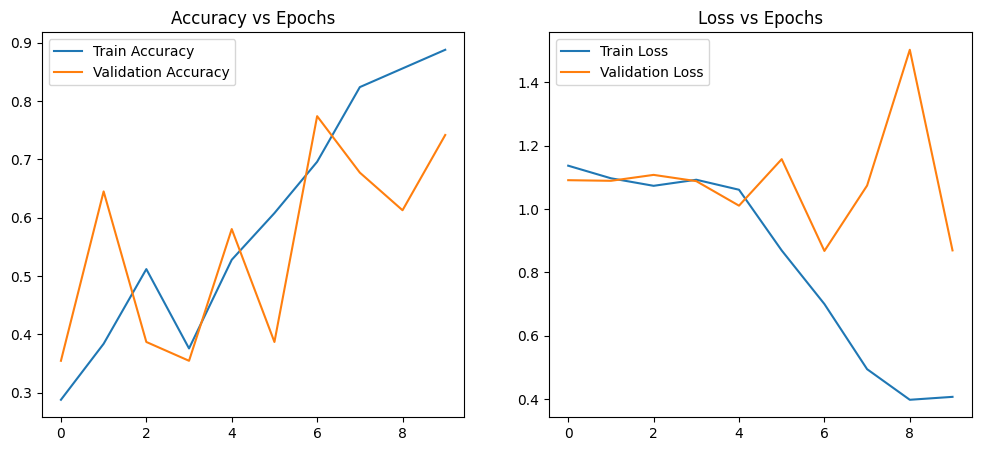

In [57]:
acc = history5.history['accuracy']
val_acc = history5.history['val_accuracy']

loss = history5.history['loss']
val_loss = history5.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [56]:
y_true = []
y_pred = []

for images, labels in val_ds_exp5:

    predictions = model5.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

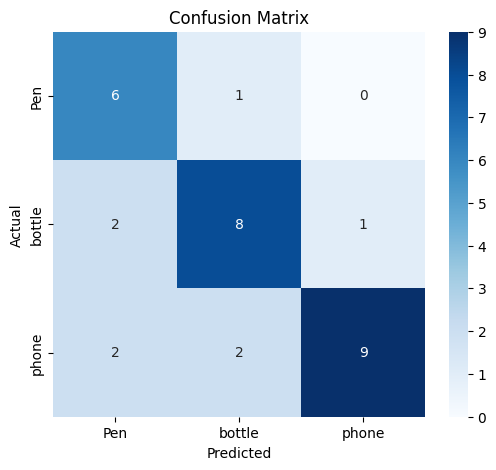

In [58]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds_exp5.class_names,
    yticklabels=train_ds_exp5.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [59]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds_exp5.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.60      0.86      0.71         7
      bottle       0.73      0.73      0.73        11
       phone       0.90      0.69      0.78        13

    accuracy                           0.74        31
   macro avg       0.74      0.76      0.74        31
weighted avg       0.77      0.74      0.75        31



In [ ]:
#Experiment : 6

In [82]:
img_height = 128
img_width = 128
batch_size = 7

train_ds_exp5 = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds_exp5 = tf.keras.utils.image_dataset_from_directory(
    "/content/ML Dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 156 files belonging to 3 classes.
Using 125 files for training.
Found 156 files belonging to 3 classes.
Using 31 files for validation.


In [61]:
model6 = Sequential([

    layers.Rescaling(1./255,
                     input_shape=(128,128,3)),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(3,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [62]:
model6.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [63]:
history6 = model6.fit(
    train_ds_exp5,
    validation_data=val_ds_exp5,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 325ms/step - accuracy: 0.3360 - loss: 1.1425 - val_accuracy: 0.3871 - val_loss: 1.0872
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 315ms/step - accuracy: 0.3760 - loss: 1.1070 - val_accuracy: 0.2258 - val_loss: 1.1065
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 380ms/step - accuracy: 0.4960 - loss: 1.0631 - val_accuracy: 0.5161 - val_loss: 1.0618
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 347ms/step - accuracy: 0.4320 - loss: 1.0541 - val_accuracy: 0.6129 - val_loss: 1.0084
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 316ms/step - accuracy: 0.5520 - loss: 0.9473 - val_accuracy: 0.5806 - val_loss: 0.9324
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 309ms/step - accuracy: 0.7280 - loss: 0.7079 - val_accuracy: 0.5161 - val_loss: 1.1201
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 381ms/step - accuracy: 0.7440 - loss: 0.5675 - val_accuracy: 0.5161 - val_loss: 1.0704
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 315ms/step - accuracy: 0.8000 - loss: 0.5857 - val_accuracy

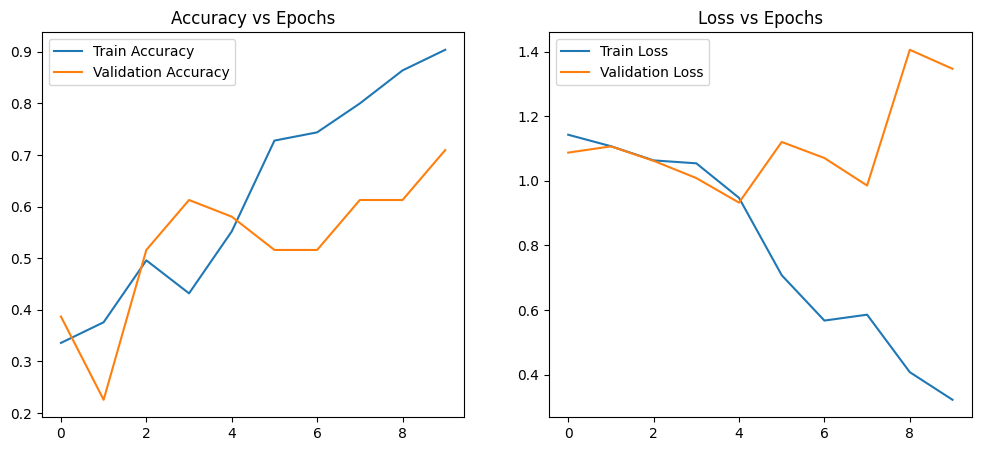

In [64]:
acc = history6.history['accuracy']
val_acc = history6.history['val_accuracy']

loss = history6.history['loss']
val_loss = history6.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

In [65]:
y_true = []
y_pred = []

for images, labels in val_ds_exp5:

    predictions = model6.predict(images, verbose=0)

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

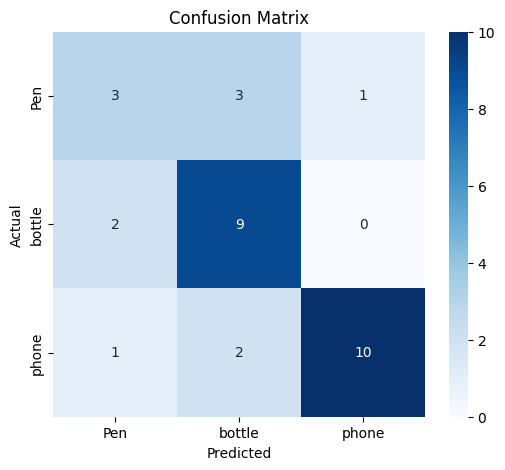

In [66]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=train_ds_exp5.class_names,
    yticklabels=train_ds_exp5.class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [67]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_ds_exp5.class_names
    )
)

              precision    recall  f1-score   support

         Pen       0.50      0.43      0.46         7
      bottle       0.64      0.82      0.72        11
       phone       0.91      0.77      0.83        13

    accuracy                           0.71        31
   macro avg       0.68      0.67      0.67        31
weighted avg       0.72      0.71      0.71        31



In [ ]:
#Experiment 7

In [87]:
model_batchnorm = Sequential([

    layers.Rescaling(
        1./255,
        input_shape=(128,128,3)
    ),

    layers.Conv2D(
        32,3,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,3,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,3,
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        3,
        activation='softmax'
    )
])

In [88]:
model_batchnorm.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
model_batchnorm.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_13 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,923 (12.61 MB)

 Trainable params: 3,305,475 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [90]:
history_batchnorm = model_batchnorm.fit(
    train_ds_exp5,
    validation_data=val_ds_exp5,
    epochs=10
)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 431ms/step - accuracy: 0.3840 - loss: 8.9043 - val_accuracy: 0.3548 - val_loss: 2.4413
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 373ms/step - accuracy: 0.6640 - loss: 5.3985 - val_accuracy: 0.4839 - val_loss: 6.0637
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 436ms/step - accuracy: 0.6480 - loss: 4.7292 - val_accuracy: 0.2258 - val_loss: 22.9130
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 437ms/step - accuracy: 0.6960 - loss: 4.7278 - val_accuracy: 0.2258 - val_loss: 25.1322
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 375ms/step - accuracy: 0.6880 - loss: 4.4019 - val_accuracy: 0.2903 - val_loss: 18.2177
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 440ms/step - accuracy: 0.7760 - loss: 2.3847 - val_accuracy: 0.2258 - val_loss: 30.7175
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 437ms/step - accuracy: 0.8560 - loss: 1.7976 - val_accuracy: 0.2258 - val_loss: 37.6604
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 371ms/step - accuracy: 0.7680 - loss: 2.1359 - val_accu

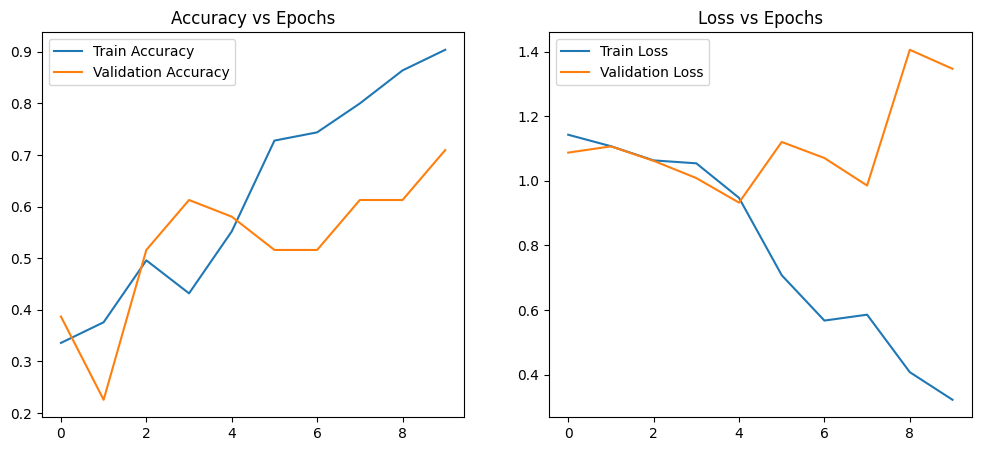

In [91]:
acc = history6.history['accuracy']
val_acc = history6.history['val_accuracy']

loss = history6.history['loss']
val_loss = history6.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()